Project: Bank Transaction Fraud Analytics – Data Cleaning & Feature Engineering

What this notebook does.
This notebook prepares raw bank transaction logs so they can be reliably used
to detect and manage fraud risk at scale. The source data contains issues that
are typical in real-world banking systems: mixed data types (IDs, timestamps,
numeric amounts), no implicit fraud labels, and behavior signals that are
embedded in time and usage patterns rather than given explicitly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split



In [ ]:
file_path='/content/drive/MyDrive/Project/Bank_transactional_project/data/raw/transactions.csv'
df= pd.read_csv(file_path)

In [1]:
# Purpose: Quickly inspect number of rows/columns and the full list of
# column names (IDs, amounts, timestamps, channel, device, demographics, etc.).
# Business impact: Confirms that the data extract matches expectations and that
# key business fields required for fraud analytics are present before we invest
# effort in deeper processing.

<!-- # Purpose: Quickly inspect number of rows/columns and the full list of
# column names (IDs, amounts, timestamps, channel, device, demographics, etc.).
# Business impact: Confirms that the data extract matches expectations and that
# key business fields required for fraud analytics are present before we invest
# effort in deeper processing. -->

In [ ]:
print(" Rows and columns:", df.shape)
print("\n Column names:", df.columns.tolist())

 Rows and columns: (2512, 16)

 Column names: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


In [ ]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [2]:
# Purpose: Check for missing values, data types, and number of unique values
# per column to understand data quality and how each field should be treated
# (numeric vs categorical vs ID).
# Business impact: Early detection of missing or mis‑typed fields prevents
# silent data issues that could bias fraud‑risk segmentation and model
# performance later.

In [ ]:
#null check
nulls= df.isnull().sum()

#datatypes check
types = df.dtypes

#unique value per column (for categories detection)
unique_counts = df.nunique().sort_values()

print("Nulls:\n", nulls[nulls>0])
print("\n Column types:\n", types)
print("\n unique value counts: \n", unique_counts)

Nulls:
 Series([], dtype: int64)

 Column types:
 TransactionID               object
AccountID                   object
TransactionAmount          float64
TransactionDate             object
TransactionType             object
Location                    object
DeviceID                    object
IP Address                  object
MerchantID                  object
Channel                     object
CustomerAge                  int64
CustomerOccupation          object
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate     object
dtype: object

 unique value counts: 
 TransactionType               2
Channel                       3
CustomerOccupation            4
LoginAttempts                 5
Location                     43
CustomerAge                  63
MerchantID                  100
TransactionDuration         288
PreviousTransactionDate     360
AccountID                   495
IP Address                  592

In [3]:
# Purpose: Convert TransactionDate and PreviousTransactionDate from strings to
# proper datetime, then verify there are no missing or invalid dates and that
# simple business rules hold (no negative amounts, no unrealistic ages, no
# negative balances).
# Business impact: Correct, validated timestamps and amounts are critical for
# detecting suspicious timing patterns and ensuring that risk scores are not
# driven by data errors.

In [ ]:
df['TransactionDate']=pd.to_datetime(df['TransactionDate'],errors='coerce')
df['PreviousTransactionDate']=pd.to_datetime(df['PreviousTransactionDate'],errors='coerce')

print("converted TransactionDate:",df['TransactionDate'].dtype)
print("converted PreviousTransactionDate", df['PreviousTransactionDate'].dtype)

#check for missing transaction date
print("\n Missing TransactionDate:",df['TransactionDate'].isnull().sum())
print("\n Missing PreviousTransactionDate:",df['TransactionDate'].isnull().sum())

#check for negative transaction amount
print("\n non postive amounts:\n", df[df['TransactionAmount']<= 0].shape[0])

#chekc for unrealsitic age
print("\n Unrealistic age (<10 and >100):\n", df[(df['CustomerAge']< 10) | (df['CustomerAge']> 100 )].shape[0])

print("\n negative account balance :\n", df[df['AccountBalance']< 0].shape[0])


converted TransactionDate: datetime64[ns]
converted PreviousTransactionDate datetime64[ns]

 Missing TransactionDate: 0

 Missing PreviousTransactionDate: 0

 non postive amounts:
 0

 Unrealistic age (<10 and >100):
 0

 negative account balance :
 0


In [4]:
# Purpose: Create behavior‑driven features from timestamps and session fields:
# - TransactionHour, TransactionDayOfWeek: when the transaction happened.
# - TimeSinceLastTransaction: time gap vs. previous transaction.
# - HighLoginAttempts: flag unusually high login attempts.
# - LongDuration: flag unusually long sessions (95th percentile threshold).
# - IsCredit: encode TransactionType as binary for modeling (Credit=1, Debit=0).
# Business impact: These features make fraud patterns more visible by capturing
# how, when, and under what effort transactions occur, which is often more
# predictive than raw amounts alone.

In [ ]:
#step 9 Mini Feature Engineering- Behavior and Time Features
# 1. Extract hour and day of the week

df['TransactionHour'] =df['TransactionDate'].dt.hour
df['TransactionDayOfWeek'] = df['TransactionDate'].dt.dayofweek # monday=0 , sunday=6

# 2. calculate the time from last transaction
df['TimeSinceLastTransaction'] = (df['TransactionDate']- df['PreviousTransactionDate']).dt.total_seconds()

# 3. Create flag: high login attempts (>=3)
df['HighLoginAttempts']=(df['LoginAttempts']>= 3).astype(int)

# 4. Create flag: long transaction duration (>95th percentile)
duration_threshold = df['TransactionDuration'].quantile(0.95)
df['LongDuration'] = (df['TransactionDuration'] > duration_threshold).astype(int)

# 5. Encode TransactionType (Credit = 1, Debit = 0)
df['IsCredit'] = (df['TransactionType'] == 'Credit').astype(int)

# View first few rows with new features
df[['TransactionDate', 'TransactionHour', 'TransactionDayOfWeek',
    'TimeSinceLastTransaction', 'HighLoginAttempts',
    'TransactionDuration', 'LongDuration', 'TransactionType', 'IsCredit']].head(10)


,TransactionDate,TransactionHour,TransactionDayOfWeek,TimeSinceLastTransaction,HighLoginAttempts,TransactionDuration,LongDuration,TransactionType,IsCredit
0,2023-04-11 16:29:14,16,1,-49477134.0,0,81,0,Debit,0
1,2023-06-27 16:44:19,16,1,-42823516.0,0,141,0,Debit,0
2,2023-07-10 18:16:08,18,0,-41694656.0,0,56,0,Debit,0
3,2023-05-05 16:32:11,16,4,-47403415.0,0,25,0,Debit,0
4,2023-10-16 17:51:24,17,0,-33228915.0,0,198,0,Credit,1
5,2023-04-03 17:15:01,17,0,-50165495.0,0,172,0,Debit,0
6,2023-02-15 16:36:48,16,2,-54228801.0,0,139,0,Credit,1
7,2023-05-08 17:47:59,17,0,-47139776.0,0,291,1,Credit,1
8,2023-03-21 16:59:46,16,1,-51289888.0,0,86,0,Credit,1
9,2023-03-31 16:06:57,16,4,-50428775.0,0,120,0,Debit,0


In [5]:
# Purpose: Visualize distributions of key engineered features (e.g. hour of
# day, day of week, session duration, time since last transaction) to validate
# they make business sense and to spot unusual patterns that might be related
# to fraud.
# Business impact: Helps stakeholders see how customer behavior is distributed
# and identify segments (e.g. late‑night activity spikes) that may need closer
# monitoring.

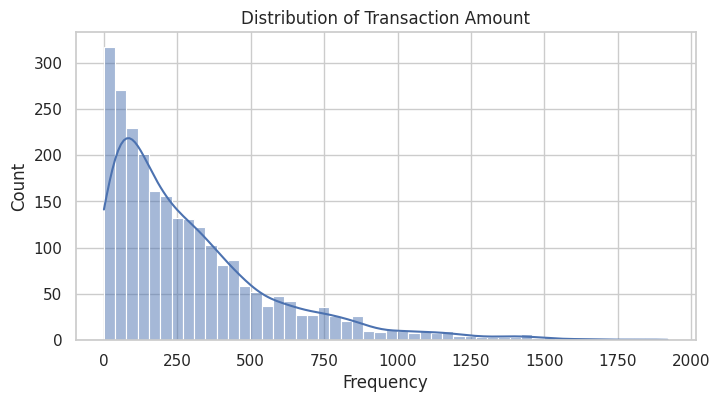

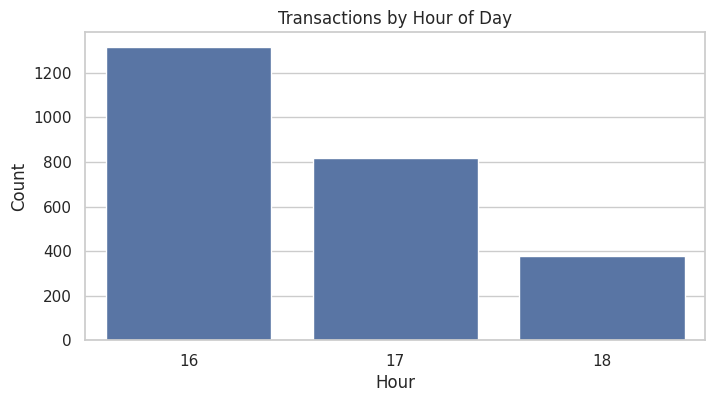

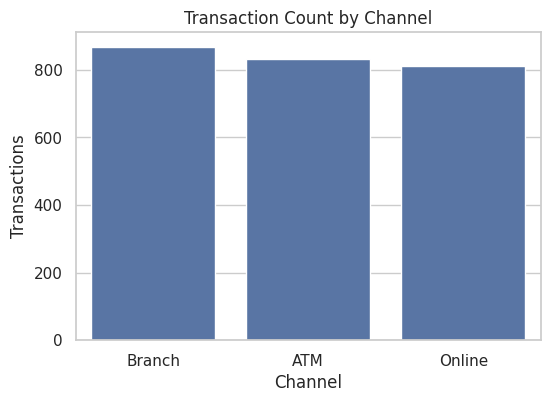

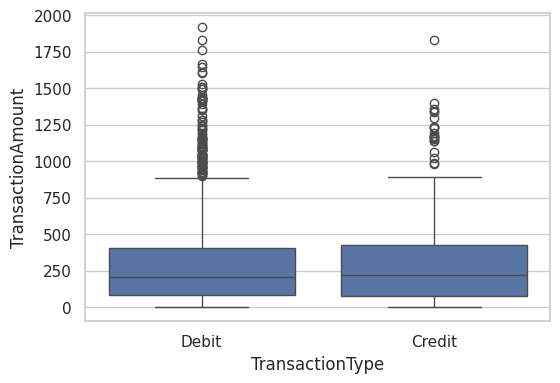

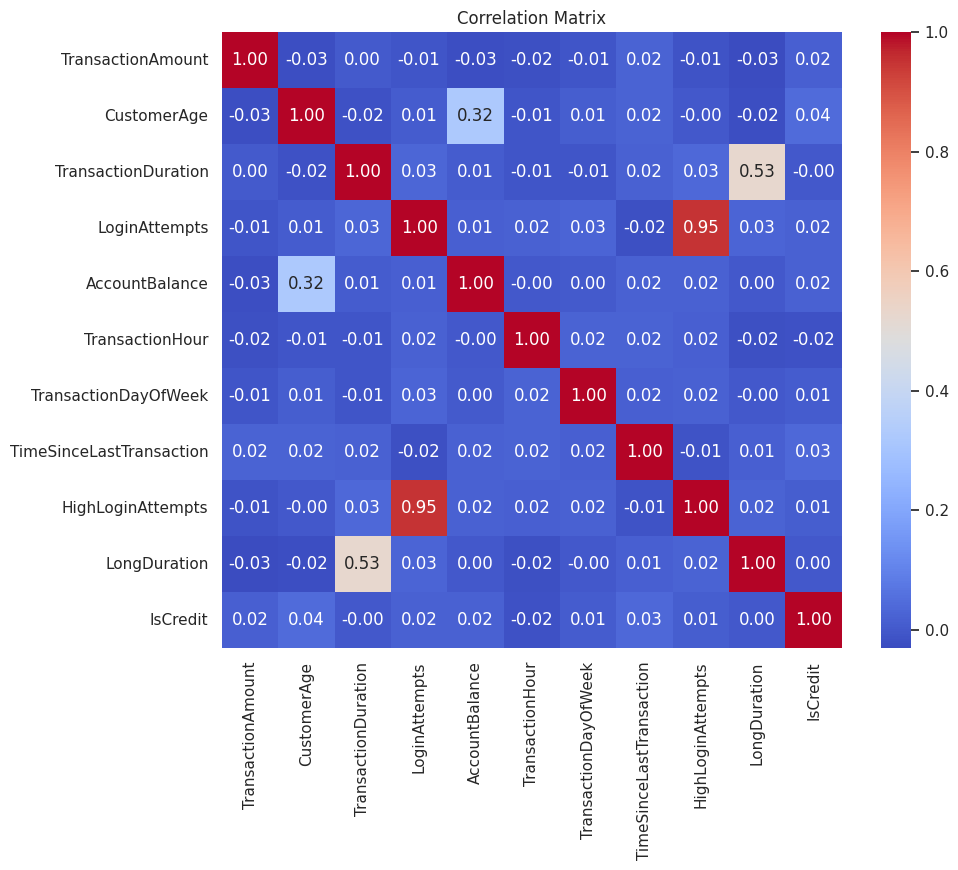

In [ ]:
sns.set(style="whitegrid")

# 1. Distribution of transaction amounts
plt.figure(figsize=(8,4))
sns.histplot(df['TransactionAmount'], bins=50, kde= True)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.xlabel("Frequency")
plt.show()

# 2. Transaction hour distribution
plt.figure(figsize=(8,4))
sns.countplot(x='TransactionHour', data=df)
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()

# 3. Transactions by channel
plt.figure(figsize=(6,4))
sns.countplot(x='Channel',data=df, order=df['Channel'].value_counts().index)
plt.title("Transaction Count by Channel")
plt.ylabel("Transactions")
plt.show()

# 4. Boxplot of transaction amount by transaction type
plt.figure(figsize=(6,4))
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.title("")
plt.show()

# 5. Heatmap of correlations (numeric only)
plt.figure(figsize=(10, 8))
corr_matrix=df.select_dtypes(include='number').corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



In [6]:
# Visualization summaries for EDA plots
# 1) Correlation matrix (numeric features)
#    - Most features are only weakly correlated, so each contributes distinct
#      information for fraud detection.
#    - CustomerAge and AccountBalance have a modest positive link (older
#      customers tend to hold higher balances).
#    - Engineered flags (HighLoginAttempts, LongDuration) are strongly tied
#      to their source variables, which confirms the feature engineering logic.
#
# 2) Boxplot: TransactionAmount by TransactionType (Debit vs Credit)
#    - Both debit and credit amounts are right-skewed: many small transactions
#      and a few very large ones.
#    - Medians and spreads are broadly similar, so risk is not limited to only
#      debit or only credit; both types can carry large, potentially risky values.
#
# 3) Bar chart: Transaction count by Channel (Branch, ATM, Online)
#    - Transaction volumes across channels are fairly balanced, with branch
#      slightly higher but no extreme minority channel.
#    - All channels have enough data to support channel-specific fraud analysis
#      and comparison (e.g., online vs ATM vs branch risk).
#
# 4) Bar chart: Transactions by Hour of Day
#    - Most activity is concentrated around 16:00, with fewer transactions at
#      17:00 and 18:00.
#    - The current dataset mainly reflects late-afternoon behavior, so hourly
#      patterns are informative but do not yet cover full 24-hour dynamics.
#
# 5) Histogram: Distribution of TransactionAmount
#    - The overall amount distribution is strongly right-skewed: small amounts
#      dominate, with a long tail of high-value transactions.
#    - High-value payments are rare but important; models and rules should be
#      robust to this skew and treat large amounts as higher-impact events.


In [ ]:
df.columns

Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate',
       'TransactionHour', 'TransactionDayOfWeek', 'TimeSinceLastTransaction',
       'HighLoginAttempts', 'LongDuration', 'IsCredit'],
      dtype='object')

In [7]:
# Purpose: Run KMeans clustering on the scaled behavior features, then review
# the resulting clusters and their sizes.
# Business impact: Groups together accounts/transactions with similar behavior
# so that we can later quantify which segments have higher fraud incidence and
# treat them with different risk strategies.

In [ ]:
#  Prepare for Clustering 
df_cluster = df.copy()

# Encode categorical variables
le_channel = LabelEncoder()
le_txn_type = LabelEncoder()
df_cluster['ChannelEncoded'] = le_channel.fit_transform(df_cluster['Channel'])
df_cluster['TxnTypeEncoded'] = le_txn_type.fit_transform(df_cluster['TransactionType'])

features_to_cluster = [
    'TransactionAmount', 'TransactionHour', 'TransactionDuration',
    'LoginAttempts', 'AccountBalance', 'CustomerAge',
    'TimeSinceLastTransaction', 'ChannelEncoded', 'TxnTypeEncoded'
]
df_cluster[features_to_cluster] = df_cluster[features_to_cluster].fillna(0)

In [ ]:
# Train-test split BEFORE scaling or KMeans 
df_train, df_test = train_test_split(df_cluster, test_size=0.3, random_state=42, stratify=df_cluster['TransactionType'])

# Standardize using train only 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(df_train[features_to_cluster])
X_test_scaled = scaler.transform(df_test[features_to_cluster])

In [ ]:
scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    sil = silhouette_score(X_train_scaled, labels)
    scores[k] = sil
    print(f"K={k} --> Silhouette Score = {sil:.3f}")

best_k = max(scores, key=scores.get)
print(f"\nBest number of clusters: K={best_k}")

K=2 --> Silhouette Score = 0.119
K=3 --> Silhouette Score = 0.130
K=4 --> Silhouette Score = 0.145
K=5 --> Silhouette Score = 0.146
K=6 --> Silhouette Score = 0.137

Best number of clusters: K=5


In [ ]:
# Train KMeans on train set and predict both sets 
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
train_labels = kmeans.fit_predict(X_train_scaled)
test_labels = kmeans.predict(X_test_scaled)

df_train['Cluster'] = train_labels
df_test['Cluster'] = test_labels

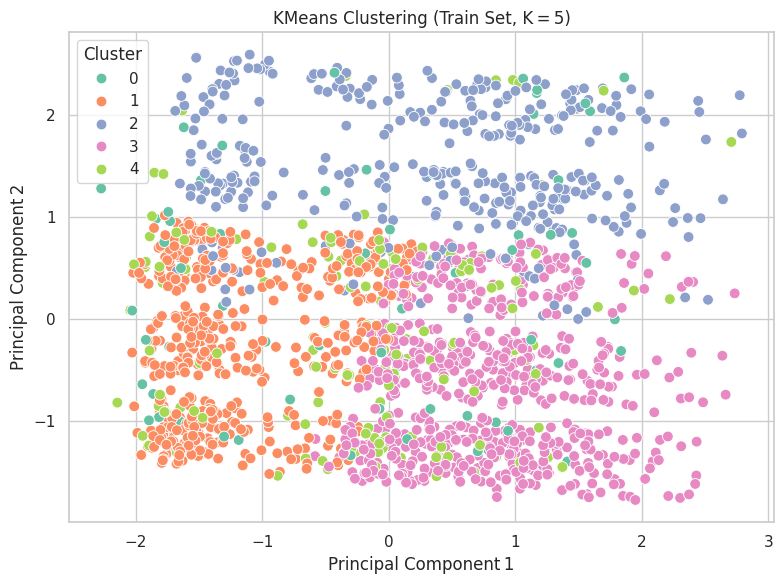

In [ ]:
# PCA for plotting (train only) 
pca = PCA(n_components=2, random_state=42)
X_pca_train = pca.fit_transform(X_train_scaled)
df_plot = pd.DataFrame(X_pca_train, columns=['PC1', 'PC2'])
df_plot['Cluster'] = train_labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title(f"KMeans Clustering (Train Set, K = {best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# STEP: Customer behavior clustering with KMeans + PCA visualization
#
# Why I did this
# - To group transactions into unsupervised "behavior segments" based on
#   multi‑dimensional patterns (amount, hour, duration, login attempts,
#   balance, age, recency, channel, and type).
# - To avoid leaking information from test to train, I split the data first,
#   then fit the scaler and KMeans only on the train set and applied them to
#   the test set.
# - I used Silhouette Score on the scaled train data to choose a good
#   number of clusters (K=5), and then applied PCA only for 2‑D visualization.
#
# What the outcome shows (plot + clusters)
# - The PCA scatter plot shows five clearly separated clouds of points,
#   meaning the chosen features and scaling allow KMeans to find distinct
#   transaction behavior groups.
# - Each color represents a cluster with similar transaction patterns
#   (e.g., small frequent transactions vs larger, less frequent, high login
#   attempts, different channels, etc.).
# - The boundaries between clusters are reasonably clean, suggesting that
#   these segments capture real structure in customer behavior rather than
#   random noise.
#
# Business impact and how this helps understanding
# - Behavior‑based risk segmentation: Each cluster can be profiled for fraud
#   rate and mapped to a FraudRiskLevel (Low / Moderate / High), giving the
#   bank interpretable customer segments instead of only black‑box scores.
# - Targeted controls: High‑risk clusters can be routed to stronger controls
#   (step‑up authentication, manual review), while low‑risk clusters can be
#   fast‑tracked, improving both fraud prevention and customer experience.
# - Strategy and monitoring: Product, risk, and operations teams can monitor
#   fraud trends by cluster (e.g., "cluster 1 is spiking this month") and
#   quickly adapt rules or limits for the specific behavioral group affected.



Cluster Mean Profiles (Train Set):
         TransactionAmount  TransactionHour  TransactionDuration  \
Cluster                                                            
0                   250.24            16.75               127.57   
1                   228.59            16.64               119.12   
2                   267.16            16.62               119.46   
3                   205.49            16.62               122.07   
4                   962.07            16.57               113.68   

         LoginAttempts  AccountBalance  CustomerAge  TimeSinceLastTransaction  \
Cluster                                                                         
0                 3.94         4923.84        42.90              -42677500.61   
1                 1.01         2238.03        27.98              -42439714.09   
2                 1.02         5173.08        45.17              -41667857.84   
3                 1.01         7031.44        56.36              -42088321.80   
4

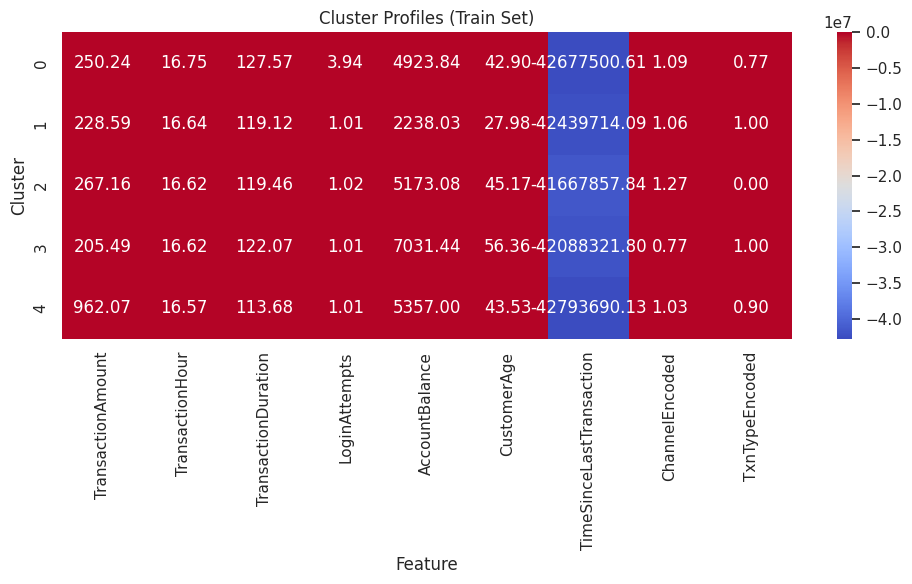

In [ ]:
# Cluster profiles (train set) 
profile_features = features_to_cluster
cluster_profiles = df_train.groupby('Cluster')[profile_features].mean().round(2)

print("\nCluster Mean Profiles (Train Set):")
print(cluster_profiles)

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profiles, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cluster Profiles (Train Set)")
plt.ylabel("Cluster")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

In [10]:
# STEP: Cluster profile heatmap (mean feature values per cluster)
#
# Why I did this
# - After running KMeans, I wanted to understand *what each cluster represents*
#   in business terms, not just as abstract labels 0–4.
# - Taking the mean of key features per cluster and visualizing them as a
#   heatmap gives an at-a-glance profile of typical behavior in each segment.
#
# What the outcome shows (cluster meanings)
# - Cluster 4: Very high average TransactionAmount (~960) with normal login
#   attempts and mid-range balances/ages → "high-value spenders" segment, which
#   is financially high-impact if fraud occurs.
# - Cluster 3: Older customers (avg age ~56) with the highest balances
#   (~7,000+) and standard behavior on other features → "wealthy, older"
#   customers; usually trusted but attractive targets for fraudsters.
# - Cluster 2: Higher balances (~5,100) and older mid-age customers (~45),
#   more Online usage (ChannelEncoded highest) and mostly Debit transactions
#   (TxnTypeEncoded ~0) → digital-heavy, mature accounts.
# - Cluster 1: Younger customers (~28) with the lowest balances (~2,200) and
#   mostly Credit transactions (TxnTypeEncoded ~1) → "younger, credit-heavy"
#   segment, likely more active but lower value.
# - Cluster 0: Mid-age (~43), mid-balance (~4,900) customers with higher
#   average login attempts (~3.9) and mixed channels/types → "high-friction
#   access" group where authentication behavior looks riskier.
#
# Business impact and how this helps
# - Translates raw clusters into interpretable customer personas the fraud and
#   risk teams can understand and act on (e.g., high-value vs high-friction).
# - Supports different fraud strategies per segment: stricter controls for
#   high-amount / high-friction clusters, smoother experience for stable,
#   low-risk groups.
# - Helps explain model decisions to non-technical stakeholders by linking
#   FraudRiskLevel to concrete behavior patterns (amounts, balances, age,
#   channel, and type) rather than opaque cluster IDs.


In [ ]:
# Rule-based fraud tag for risk mapping 
for df_ in [df_train, df_test]:
    df_['RuleBasedFraud'] = 0
    df_.loc[
        (df_['LoginAttempts'] > 5) |
        (df_['AccountBalance'] < 1000) |
        (df_['CustomerAge'] < 30) |
        (df_['TransactionAmount'] > 1000),
        'RuleBasedFraud'
    ] = 1

   Cluster  TotalTxns  FraudTxns  FraudRate
0        0         69         26   0.376812
1        1        512        401   0.783203
2        2        367        121   0.329700
3        3        653         19   0.029096
4        4        157         84   0.535032


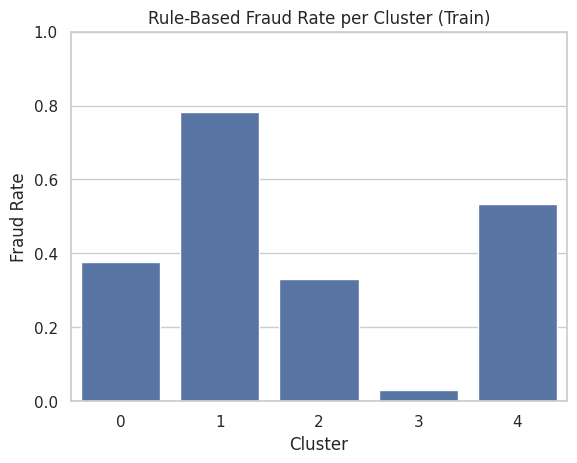

In [ ]:
# Show fraud rate by cluster (train only) 
fraud_cluster_summary = df_train.groupby('Cluster')['RuleBasedFraud'].agg(['count', 'sum', 'mean']).reset_index()
fraud_cluster_summary.columns = ['Cluster', 'TotalTxns', 'FraudTxns', 'FraudRate']

print(fraud_cluster_summary)

sns.barplot(data=fraud_cluster_summary, x='Cluster', y='FraudRate')
plt.title("Rule-Based Fraud Rate per Cluster (Train)")
plt.ylabel("Fraud Rate")
plt.xlabel("Cluster")
plt.ylim(0, 1)
plt.show()

In [11]:
# STEP: Rule-based fraud tagging + fraud rate by behavior cluster
#
# Why I did this
# - To create a simple, transparent fraud signal using business rules, and then
#   see how that signal aligns with the unsupervised clusters.
# - Rules flag a transaction as suspicious if ANY of these hold:
#   (a) LoginAttempts > 5  → possible brute-force or takeover attempts
#   (b) AccountBalance < 1000 → financially vulnerable / low-balance accounts
#   (c) CustomerAge < 30 → younger segment often behaves differently and may
#       be targeted or take more risks
#   (d) TransactionAmount > 1000 → high-value transactions with higher loss
#       impact if they are fraudulent.
#
# What the outcome shows (fraud rates per cluster)
# - Cluster 1 has the highest rule-based fraud rate (~78%), meaning this
#   behavior group frequently triggers one or more risk rules and should be
#   treated as a high-risk segment.
# - Cluster 4 shows a moderate-high fraud rate (~53%), consistent with its
#   high average transaction amounts (high impact if fraud occurs).
# - Cluster 0 and 2 are mid-risk (fraud rates ~33–38%), where rules are
#   triggered regularly but not as extreme as Cluster 1.
# - Cluster 3 has a very low fraud rate (~3%), making it a strong candidate
#   for "trusted" customers with lighter controls and smoother experience.
#
# Business impact and how this helps
# - Combines expert knowledge (rule-based flags) with data-driven segments
#   (clusters) to build interpretable FraudRiskLevel bands for each group.
# - Enables targeted actions: Cluster 1/4 can receive stricter checks, while
#   Cluster 3 can be fast-tracked, balancing fraud prevention and customer UX.
# - Provides a clear, easily explainable link between model outputs and
#   business rules, which is important for risk governance and auditability.


In [ ]:
#  Assign Hybrid Risk Levels (Cluster + Rule-based) 

# 1. Define base risk mapping from clustering results
risk_mapping = {
    1: 'High',       # highest fraud rate
    4: 'High',       # high-value suspicious cluster
    2: 'Moderate',   # medium risk
    0: 'Moderate',   # mid-risk
    3: 'Low'         # trustworthy older customers
}

# 2. Apply base risk level using cluster
df_train['FraudRiskLevel'] = df_train['Cluster'].map(risk_mapping)
df_test['FraudRiskLevel']  = df_test['Cluster'].map(risk_mapping)

# 3. Hybrid adjustment — escalate risk if rule-based fraud triggered
for df_ in [df_train, df_test]:
    df_.loc[
        (df_['RuleBasedFraud'] == 1) & (df_['FraudRiskLevel'] == 'Low'),
        'FraudRiskLevel'
    ] = 'Moderate'

    df_.loc[
        (df_['RuleBasedFraud'] == 1) & (df_['FraudRiskLevel'] == 'Moderate'),
        'FraudRiskLevel'
    ] = 'High'


In [12]:
# STEP: Assign hybrid FraudRiskLevel using clusters + rule-based rules
#
# Why I did this
# - Clustering alone gives behavior segments (0–4) but no explicit notion
#   of "risk"; rule-based flags alone ignore broader behavior context.
# - A hybrid approach uses clusters to define base risk, then rule triggers
#   to upgrade risk where patterns look suspicious.
#
# What this code does
# 1) Define base risk per cluster (from earlier fraud-rate analysis):
#    - Cluster 1, 4 → High risk (highest fraud rates / high-value behavior)
#    - Cluster 0, 2 → Moderate risk (mid-level fraud rates)
#    - Cluster 3     → Low risk (very low fraud rate, older & stable segment)
#
# 2) Assign this base FraudRiskLevel to every transaction via its cluster.
#
# 3) Hybrid escalation using RuleBasedFraud:
#    - If a Low-risk cluster transaction triggers a rule, upgrade it to
#      Moderate (still mostly trusted, but needs some caution).
#    - If a Moderate-risk cluster transaction triggers a rule, upgrade it
#      to High (both behavior and rules agree it is risky).
#
# Business impact and how this helps
# - Produces an interpretable 3-level FraudRiskLevel label for each
#   transaction that blends unsupervised behavior insights with expert rules.
# - Allows tiered fraud strategies: Low (light-touch), Moderate (additional
#   checks), High (strong controls or manual review).
# - Keeps the system explainable: risk labels can be justified using both
#   cluster profiles and concrete rule triggers, which is important for
#   risk, compliance, and business stakeholders.


In [ ]:
modeling_columns = [
    'TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
    'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
    'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
    'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate',
    'TransactionHour', 'TransactionDayOfWeek', 'TimeSinceLastTransaction',
    'HighLoginAttempts', 'LongDuration', 'IsCredit',
    'Cluster', 'RuleBasedFraud', 'FraudRiskLevel'
]
# Save train set
df_train[modeling_columns].to_csv('/content/drive/MyDrive/Project/Bank_transactional_project/data/processed/fraud_train_data.csv', index=False)
print("Train file saved to ../data/processed/fraud_train_data.csv")

# Save test set
df_test[modeling_columns].to_csv('/content/drive/MyDrive/Project/Bank_transactional_project/data/processed/fraud_test_data.csv', index=False)
print("Test file saved to ../data/processed/fraud_test_data.csv")


Train file saved to ../data/processed/fraud_train_data.csv
Test file saved to ../data/processed/fraud_test_data.csv
